# Besoin du Client 1 : Visualisation sur carte


## Objectif :

***L'identification et la localisation des points de charges avec leur type et la détection d'éventuelles anomalies***

**Etapes :**

1 : Chargement et préparation des données  
2 : Visualisation des données      
3 : Visualisation sur carte selon le type d'implantation et/ou de la puissance nominale  
4 : Création d'une carte de chaleur pour représenter la densité spatiale des bornes

## I. Chargement et préparation des données



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Librairie pour visualiser sur carte
import folium
from folium.plugins import MarkerCluster
from folium import Element
from folium.plugins import HeatMap

# Importation du drive google
from google.colab import drive



In [4]:
# Importation de mon drive google personnel
drive.mount('/content/drive')

Mounted at /content/drive


#### I. Lecture du fichier CSV

In [28]:
#Lecture du fichier en local
# Le chemin est a changer en fonction de votre machine et de vos données
chemin = "/content/drive/MyDrive/Projet_IA_S6/export_ia.csv"
data = pd.read_csv(chemin)
data.info()

/tmp/ipykernel_3171/3261455935.py:2: DtypeWarning: Columns (13,19,20,21,22,23,25,30,34) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/content/drive/MyDrive/Projet_IA_S6/export_ia.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141415 entries, 0 to 141414
Data columns (total 53 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Unnamed: 0                           141415 non-null  int64  
 1   nom_amenageur                        141021 non-null  object 
 2   siren_amenageur                      80341 non-null   float64
 3   contact_amenageur                    80993 non-null   object 
 4   nom_operateur                        137174 non-null  object 
 5   contact_operateur                    141415 non-null  object 
 6   telephone_operateur                  99238 non-null   object 
 7   nom_enseigne                         141415 non-null  object 
 8   id_station_itinerance                141415 non-null  object 
 9   id_station_local                     89138 non-null   object 
 10  nom_station                          141415 non-null  object 
 11  implantation_

En observant le résultat on remarque que la pluplarts des colonnes sont sous la forme d'objet panda, or pour la suite la visualisation il vaut mieux les convertir dans le format idéal.  
Ainsi on enlève les données qui ne nous intéressent pas et on les convertis.

#### II. Données formatées

In [38]:
# Sélection colonnes utiles
colonnes_utiles = [
    'nom_station',
    'implantation_station',
    'puissance_nominale',
    'nbre_pdc',
    'lat',
    'long',
    'prise_type_ef',
    'prise_type_2',
    'prise_type_combo_ccs',
    'prise_type_chademo',
    'prise_type_autre'
]

# On enlève les autres colonnes
data = data[colonnes_utiles]

# On convertis les données
data['nom_station'] = data['nom_station'].astype(str)
data['implantation_station'] = data['implantation_station'].astype(str)
data['prise_type_ef'] = data['prise_type_ef'].astype(bool)
data['prise_type_2'] = data['prise_type_2'].astype(bool)
data['prise_type_combo_ccs'] = data['prise_type_combo_ccs'].astype(bool)
data['prise_type_chademo'] = data['prise_type_chademo'].astype(bool)
data['prise_type_autre'] = data['prise_type_autre'].astype(bool)

# On enlève les données null
data_propre = data.dropna(subset=['lat','long','implantation_station'])

print("Nouvelle taille en mémoire :")
data.info()

Nouvelle taille en mémoire :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141415 entries, 0 to 141414
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   nom_station           141415 non-null  object 
 1   implantation_station  141415 non-null  object 
 2   puissance_nominale    141387 non-null  float64
 3   nbre_pdc              141415 non-null  int64  
 4   lat                   141415 non-null  float64
 5   long                  141415 non-null  float64
 6   prise_type_ef         141415 non-null  bool   
 7   prise_type_2          141415 non-null  bool   
 8   prise_type_combo_ccs  141415 non-null  bool   
 9   prise_type_chademo    141415 non-null  bool   
 10  prise_type_autre      141415 non-null  bool   
dtypes: bool(5), float64(3), int64(1), object(2)
memory usage: 7.1+ MB


Nos données sont finalement utilisable et elles prennent beaucoup moins de place en mémoire : chargement plus rapide (54.4MB -> 7.1 MB)

## II. Visualisation des données

Dans cette partie on souhaites bien comprendre le jeu de données et de réaliser comment les données sont réparties.

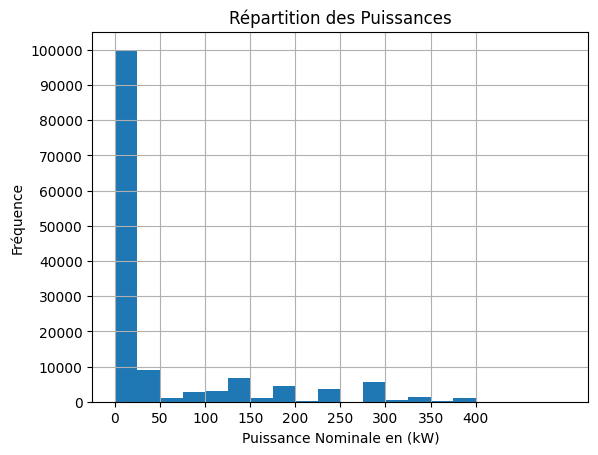

In [25]:
# Répartition des puissances nominales
data['puissance_nominale'].plot(kind='hist',bins=20,title="Répartition des Puissances")

plt.xlabel("Puissance Nominale en (kW)")
plt.ylabel("Fréquence")
plt.xticks(range(0,401,50))
plt.yticks(range(0,100001,10000))
plt.grid(True)
plt.show()

On remarque que les bornes tournent majoritairement entre 0 et 50kW

###

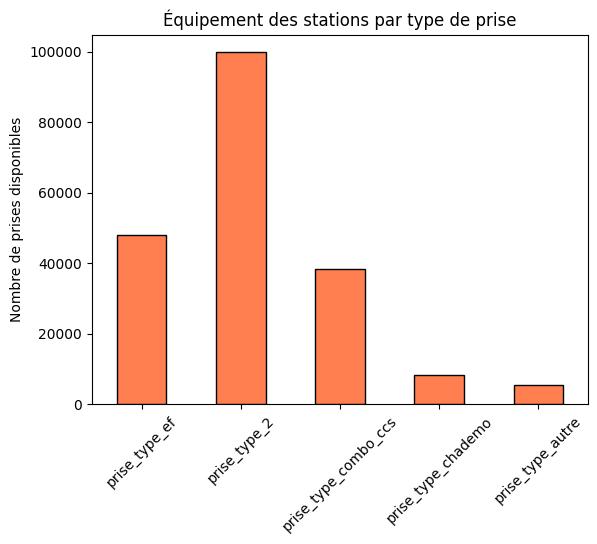

In [33]:
# On regroupe les noms de tes colonnes de prises dans une liste
colonnes_prises = [
    'prise_type_ef', 'prise_type_2', 'prise_type_combo_ccs',
    'prise_type_chademo', 'prise_type_autre'
]

# On calcule la somme de chaque colonne d'un seul coup
total_par_prise = data[colonnes_prises].sum()


total_par_prise.plot(kind='bar', color='coral', edgecolor='black')

plt.title("Équipement des stations par type de prise")
plt.ylabel("Nombre de prises disponibles")
plt.xticks(rotation=45) # Inclinaison
plt.show()


On remarque que la grande majorité des bornes ont des prises de type 2 le reste se joue entre les prises de type ef et combo ccs.

## III. Visualisation sur carte selon le type d'implantation et/ou de la puissance nominale :

#### 1. Carte selon le type d'implantation

Ici on réalise les cartes de visualisation grâce a la librairie folium   

In [34]:
# On visualise les différents champs
data["implantation_station"].unique()

array(['voirie', 'parking public', 'station dédiée à la recharge rapide',
       'parking privé à usage public',
       'parking privé réservé à la clientèle'], dtype=object)

In [35]:
# On enlève les données null
data_propre = data.dropna(subset=['lat','long','implantation_station'])

On prend la moyenne des longitudes et latitudes pour avoir une vision centrées sur celles-ci

In [36]:
# Latitude = Nord & Sud
centre_lat = data['lat'].mean()
# Longitude = Ouest & Est
centre_long = data['long'].mean()

Pour éviter d'avoir 141000 données, on garde uniquement un point pour une station avec plusieurs bornes de recharge

In [ ]:
# Regroupement par la première apparition du contenu
stations_impl = data_propre.groupby(['lat','long','implantation_station']).agg(
    implantation=('implantation_station','first'),
    nom=('nom_station','first'),
    puissance_nominale=('puissance_nominale','first'),
    nbre_pdc=('nbre_pdc','first'
)).reset_index()


Par soucis d'affichage sur la carte en javascript il est nécessaire d'enlever les apostrophes, guillemets et les retours à la ligne cachés par des espaces

In [ ]:
# On s'assure que tout est bien au format texte
stations_impl['nom'] = stations_impl['nom'].astype(str)
stations_impl['implantation'] = stations_impl['implantation'].astype(str)

# On remplace les apostrophes, guillemets, et les retours à la ligne cachés par des espaces
# Regex pour expressions régulières
stations_impl['nom'] = stations_impl['nom'].replace(r'[\'\"`\n\r]+', ' ', regex=True)
stations_impl['implantation'] = stations_impl['implantation'].replace(r'[\'\"`\n\r]+', ' ', regex=True)

# On remplace les données manque par inconnu pour le js
stations_impl = stations_impl.fillna("Inconnu")

On arrive maintenant a la création de la carte :  
En premier on crée la carte, ensuite un calque, un cluster et pour finir les points

In [ ]:
# Carte -> Calque -> Cluster -> Point
#Création de la carte
map_implantation = folium.Map(location=[centre_lat, centre_long], zoom_start=6)

# Récupération des types d'implantation
types_uniques = data["implantation_station"].unique()
couleurs_implantation = ['green', 'blue', 'purple', 'orange', 'red']


# Création du dictionnaire clusteurs
clusters = {}


# Boucle pour les clusteurs
# Enumerate : index et contenu
for index, type_impl in enumerate(types_uniques):
  calque = folium.FeatureGroup(name=str(type_impl))
  cluster = MarkerCluster().add_to(calque)
  calque.add_to(map_implantation)


  couleur = couleurs_implantation[index % len(couleurs_implantation)]
  clusters[type_impl] = {'cluster' : cluster, 'couleur' : couleur}

Pour continuer on regroupe les données et on itère dessus pour pouvoir ajouter les points à la carte

In [ ]:
# Regroupe les données pour avoir une itération plus facile
lignes_gardees = zip(stations_impl['lat'], stations_impl['long'],stations_impl['nom'],stations_impl['puissance_nominale'],stations_impl['nbre_pdc'], stations_impl['implantation_station'])

# Itération pour l'affichage des données
for lat, lon, station, puissance, nb_pdc, implantation in lignes_gardees:
  # Texte de survol
  texte_bulle = f"<b>📍 {station}</b><br> <i>{implantation}</i><br> ⚡ {puissance} kW<br>🔋 {nb_pdc} prise(s)"

  # Couleur et appartenance des points a un cluster
  couleur_cible = clusters[implantation]['couleur']
  cluster_cible = clusters[implantation]['cluster']

  folium.Marker(location=[lat, lon],
                tooltip=texte_bulle,
                icon=folium.Icon(color=couleur_cible)
  ).add_to(cluster_cible)

Pour finir on crée la légende en html vu que l'export sera en html de la carte.

In [37]:




#Légende html
lignes_html = ""

# Itération sur les noms de labels, pour avoir la couleur
for type_impl, infos in clusters.items():
  couleur = infos['couleur']

  lignes_html += f"""
    <div style="display: flex; align-items: center; margin-bottom: 8px;">
        <span style="background-color: {couleur}; width: 15px; height: 15px; border-radius: 50%; display: inline-block; margin-right: 10px; border: 1px solid #555;"></span>
        <span>{type_impl}</span>
    </div>
   """
# Code pour la légende en bas a gauche
code_html_legende = f"""
  <div style="
      position: fixed;
      bottom: 30px;
      left: 30px;
      width: 220px;
      z-index: 9999;
      background-color: rgba(255, 255, 255, 0.95);
      padding: 15px;
      border-radius: 8px;
      border: 2px solid #ccc;
      box-shadow: 3px 3px 10px rgba(0,0,0,0.2);
      font-family: 'Arial', sans-serif;
      font-size: 14px;
      color: #333;
  ">
      <h4 style="margin-top: 0; margin-bottom: 12px; border-bottom: 1px solid #ccc; padding-bottom: 5px; text-align: left;">Types d'implantation</h4>
      {lignes_html}
</div>
  """

# Ajout de la légende a la carte
map_implantation.get_root().html.add_child(Element(code_html_legende))



On exporte la carte et on ajoute les élements a celle-ci.

In [ ]:

folium.LayerControl().add_to(map_implantation)
map_implantation.save("map_implantation.html")

#### 2. Carte selon la puissance nominale

In [11]:
# Observation des données pour faire la carte
# 0 - 24kW puissance Normale
# 25 - 150kW puissance rapide
# >150kW puissance extrèmement rapide
data["puissance_nominale"].value_counts().head(20)


,count
puissance_nominale,
22.00,58527
7.40,11559
7.00,10100
50.00,6805
150.00,6704
22.08,5681
300.00,5572
250.00,3478
120.00,3023


Ici on se retrouve dans le même cas que la carte d'avant :  
Création de la carte, le calque, le cluster, les points et la légende pour l'exporter en html.  
Un changement majeur est que les clusteurs sont faits à partir des puissance nominales qu'on a regroupés en normale, rapide, extrêmement rapide.

In [12]:
# Création de la carte
map_puissance = folium.Map(location=[centre_lat, centre_long], zoom_start=6)


# Regroupement des borne de recharge par stations
stations_pui = data_propre.groupby(['lat', 'long']).agg(
    nom=('nom_station', 'first'),
    implantation=('implantation_station', 'first'),
    puissance_max=('puissance_nominale', 'max'),
    nb_pdc=('puissance_nominale', 'count')
).reset_index()

# Nettoyage
stations_pui['nom'] = stations_pui['nom'].astype(str).replace(r'[\'\"`\n\r]+', ' ', regex=True)
stations_pui['implantation'] = stations_pui['implantation'].astype(str).replace(r'[\'\"`\n\r]+', ' ', regex=True)
stations_pui = stations_pui.fillna("Inconnu")


# Regroupement des puissances
limites_puissance = [0, 24, 150, np.inf]
nom_labels = ["Normale (0-24kW)","Rapide (25-150kW)","Extrêmement Rapide (>150kW)"]

# Changement des valeurs en fonctin des intervalles
nb_valeurs_pui = pd.cut(stations_pui["puissance_max"],bins=limites_puissance,labels=nom_labels)
nb_valeurs_pui.value_counts()

# Couleurs de puissance
couleurs_puissance = ['lightgreen','orange','red']

clusters = {}

# Définition des clusters / calque
for index, puissance in enumerate(nom_labels):
  calque = folium.FeatureGroup(name=str(puissance))
  cluster = MarkerCluster().add_to(calque)

  calque.add_to(map_puissance)
  couleur = couleurs_puissance[index]

  clusters[puissance] = {'cluster' : cluster, 'couleur' : couleur}


lignes_gardees = zip(stations_pui['lat'],stations_pui['long'],stations_pui['nom'],stations_pui['puissance_max'],nb_valeurs_pui,stations_pui['nb_pdc'], stations_pui['implantation'],)


# Itération pour l'affichage des données
for lat, lon, station, pui_chiffre, pui_texte, nb_pdc, implantation in lignes_gardees:

  texte_popup = f"<b>📍 {station}</b><br> <i>{pui_texte}</i><br> ⚡ {pui_chiffre} kW<br>🔋 {nb_pdc} prise(s)"

  couleur_cible = clusters[pui_texte]['couleur']
  cluster_cible = clusters[pui_texte]['cluster']

  folium.Marker(location=[lat, lon],
                popup=folium.Popup(texte_popup, max_width=300, min_width=200),
                icon=folium.Icon(color=couleur_cible)
  ).add_to(cluster_cible)

#Légende html
lignes_html = ""

# Même chose que dans le cas de la première carte
for nom_labels, infos in clusters.items():
  couleur = infos['couleur']

  # Légende des différents point
  lignes_html += f"""
    <div style="display: flex; align-items: center; margin-bottom: 8px;">
        <span style="background-color: {couleur}; width: 15px; height: 15px; border-radius: 50%; display: inline-block; margin-right: 10px; border: 1px solid #555;"></span>
        <span>{nom_labels}</span>
    </div>
   """
# Légende en bas a gauche contenant les éléments d'avant
code_html_legende = f"""
  <div style="
      position: fixed;
      bottom: 30px;
      left: 30px;
      width: 220px;
      z-index: 9999;
      background-color: rgba(255, 255, 255, 0.95);
      padding: 15px;
      border-radius: 8px;
      border: 2px solid #ccc;
      box-shadow: 3px 3px 10px rgba(0,0,0,0.2);
      font-family: 'Arial', sans-serif;
      font-size: 14px;
      color: #333;
  ">
      <h4 style="margin-top: 0; margin-bottom: 12px; border-bottom: 1px solid #ccc; padding-bottom: 5px; text-align: left;">Types d'implantation</h4>
      {lignes_html}
</div>
  """

# Ajout de la légende
map_puissance.get_root().html.add_child(Element(code_html_legende))

# Ajout des éléments a la carte
folium.LayerControl().add_to(map_puissance)

#Export
map_puissance.save("map_puissance.html")


## IV: Heat Map des bornes de recharge

La carte est réalisé également avec la librairie folium mais avec une extension différente : HeatMap

On regroupe idéalement les données pour pouvoir les utilisées avec folium

In [40]:
# On regroupe les latitudes et longitudes non null sous la forme de tableaux
data_propre[['lat','long']].values.tolist()

[[16.237882, -61.572327],
 [16.237882, -61.572327],
 [16.271696, -61.636493],
 [16.271696, -61.636493],
 [48.967183, 4.799711],
 [48.967183, 4.799711],
 [48.967183, 4.799711],
 [48.967183, 4.799711],
 [51.005589, 2.192848],
 [43.117013, 0.760407],
 [43.117013, 0.760407],
 [43.117013, 0.760407],
 [43.117013, 0.760407],
 [43.117013, 0.760407],
 [43.117013, 0.760407],
 [47.613291, 1.336631],
 [47.613291, 1.336631],
 [47.613291, 1.336631],
 [50.731311, 2.277671],
 [48.554611, 3.286941],
 [47.613291, 1.336631],
 [47.613291, 1.336631],
 [47.613291, 1.336631],
 [48.052051, 0.166481],
 [50.385751, 3.137621],
 [50.385751, 3.137621],
 [50.385751, 3.137621],
 [45.156133, 5.733263],
 [45.156133, 5.733263],
 [45.156133, 5.733263],
 [45.156133, 5.733263],
 [49.264311, 3.967443],
 [49.264311, 3.967443],
 [49.264311, 3.967443],
 [48.188471, 6.470891],
 [48.188471, 6.470891],
 [48.188471, 6.470891],
 [48.188471, 6.470891],
 [48.188471, 6.470891],
 [48.188471, 6.470891],
 [48.188471, 6.470891],
 [48.188

In [22]:
# Création de la carte
map_chaleur = folium.Map([centre_lat,centre_long], zoom_start=6)

# Conversion
donnees_chaleur = data_propre[['lat','long']].values.tolist()

# HeatMap & Conversion en html
HeatMap(donnees_chaleur, radius=10, blur=10).add_to(map_chaleur)
map_chaleur.save("map_chaleur.html")